# Pythia EFPs with NTK 

Compares the EFP covariance eigenspectrum for two processes at the same center-of-mass energy (sqrt(s) = mZ = 91.188 GeV):
- **e+e- → Z → qqbar** (light quarks u, d, s)
- **e+e- → H → gg** with mH = mZ (gluon jets)

Events are generated with Pythia8. EFPs are computed with [EnergyFlow](https://energyflow.network) package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import energyflow as ef
from energyflow.utils import gen_massless_phase_space
from energyflow import EFPSet
import os
import time
from RegressFunctions import *
from RestrictedEFPs import efps_chunked
from PhysicsFunctions import *

os.makedirs('figures', exist_ok=True)

In [2]:
import importlib, PhysicsFunctions; importlib.reload(PhysicsFunctions)
from PhysicsFunctions import *

## Load Pythia Events

Text format: one particle per line (`E px py pz`), blank line between events.

In [3]:
#########################################################
### Load events from my Pythia simulation 
#########################################################
def load_events(filepath):
    events, current = [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                current.append([float(x) for x in line.split()])
            elif current:
                events.append(np.array(current))
                current = []
    if current:
        events.append(np.array(current))
    return events


Zqq_events = load_events('data/Zqq_events.txt')
Zqq_events_p08 = load_events('data/Zqq_events_as0.08_fixed.txt')
Zqq_events_p12 = load_events('data/Zqq_events_as0.12_fixed.txt')
Zqq_events_p16 = load_events('data/Zqq_events_as0.16_fixed.txt')
Hgg_events = load_events('data/Hgg_events.txt')

mults_Z = [len(e) for e in Zqq_events]
mults_H = [len(e) for e in Hgg_events]
print(f'Z->qqbar: {len(Zqq_events)} events, avg multiplicity {np.mean(mults_Z):.1f} +/- {np.std(mults_Z):.1f}')
print(f'H->gg:    {len(Hgg_events)} events, avg multiplicity {np.mean(mults_H):.1f} +/- {np.std(mults_H):.1f}')


#########################################################
### Load events from zqq_splittings folder 
#########################################################
def load_splittings(k, folder='data/zqq_splittings'):
    """Z->qqbar partons after the k-th shower branching.
    Returns array (N_k, 2+k, 4) with columns (E, px, py, pz)."""
    return np.load(f'{folder}/splittings_{k}.npy').astype(np.float64)

Zqq_events_1 = load_splittings(1)   # 3 partons
Zqq_events_2 = load_splittings(2)   # 4 partons
Zqq_events_3 = load_splittings(3)   # 5 partons
Zqq_events_4 = load_splittings(4)   # 6 partons

for k, ev in enumerate([Zqq_events_1, Zqq_events_2, Zqq_events_3, Zqq_events_4], start=1):
    print(f'Z->qqbar, {k} splitting(s): {ev.shape[0]} events, {ev.shape[1]} partons each')

Z->qqbar: 100000 events, avg multiplicity 12.4 +/- 4.2
H->gg:    100000 events, avg multiplicity 19.9 +/- 5.2
Z->qqbar, 1 splitting(s): 99387 events, 3 partons each
Z->qqbar, 2 splitting(s): 98800 events, 4 partons each
Z->qqbar, 3 splitting(s): 96813 events, 5 partons each
Z->qqbar, 4 splitting(s): 93358 events, 6 partons each


In [4]:
#### Uniform Phase Space ####

NEvents=100_000
uniform_N3 = gen_massless_phase_space(NEvents,3,energy=1.0)
uniform_N4 = gen_massless_phase_space(NEvents,4,energy=1.0)
uniform_N5 = gen_massless_phase_space(NEvents,5,energy=1.0)
uniform_N7 = gen_massless_phase_space(NEvents,7,energy=1.0)
uniform_N10 = gen_massless_phase_space(NEvents,10,energy=1.0)

# efpset = EFPSet(('d<=', 6), measure='eeefm', beta=2,coords='epxpypz')

## Load Features, Compute Covariances, Eigenspectra

In [5]:
labels = {'u3': 'uniform $N=3$', 'u4': 'uniform $N=4$', 'u5': 'uniform $N=5$', 'u6': 'uniform $N=6$', 'u7': 'uniform $N=7$', 'u10': 'uniform $N=10$',
          'Z': r'$Z\to q\bar q$', 
          'Z08': r'$Z\to q\bar q$, fixed $\alpha_s$=0.08', 'Z12': r'$Z\to q\bar q$, fixed $\alpha_s$=0.12', 'Z16': r'$Z\to q\bar q$, fixed $\alpha_s$=0.16',
          'Z1': r'$Z\to q\bar q$, 1 splitting', 'Z2': r'$Z\to q\bar q$, 2 splittings',
          'Z3': r'$Z\to q\bar q$, 3 splittings', 'Z4': r'$Z\to q\bar q$, 4 splittings',
          'H': r'$H\to gg$',}

In [6]:
#########################################################
### Load features (computed in make_features.ipynb)
#########################################################
F = np.load('features/EFPs_restricted_d13.npz')
EFP_sets = {k: F[k] for k in F.files if k != 'dmax'}     # keys: u3, u4, u5, u6, u7, u10, Z1..Z4
# SIJ_sets = dict(np.load('features/SIJ.npz'))              # same keys, same events
SIJ_sets = {k: v for k, v in np.load('features/SIJ.npz').items() if v.shape[1] > 1}
QVC_sets = dict(np.load('features/QVEC_nq64.npz'))          
print('EFP:', {k: v.shape for k, v in EFP_sets.items()})
print('SIJ:', {k: v.shape for k, v in SIJ_sets.items()})
print('Qvc:', {k: v.shape for k, v in QVC_sets.items()})

EFP: {'u3': (100000, 109), 'u4': (100000, 109), 'u5': (100000, 109), 'u6': (100000, 109), 'u7': (100000, 109), 'u10': (100000, 109), 'Z': (100000, 109), 'Z08': (100000, 109), 'Z12': (100000, 109), 'Z16': (100000, 109), 'Z1': (99387, 109), 'Z2': (98800, 109), 'Z3': (96813, 109), 'Z4': (93358, 109)}
SIJ: {'u3': (100000, 3), 'u4': (100000, 6), 'u5': (100000, 10), 'u6': (100000, 15), 'u7': (100000, 21), 'u10': (100000, 45), 'Z': (100000, 15), 'Z1': (99387, 3), 'Z2': (98800, 6), 'Z3': (96813, 10), 'Z4': (93358, 15), 'H': (100000, 66)}
Qvc: {'u3': (100000, 64), 'u4': (100000, 64), 'u5': (100000, 64), 'u6': (100000, 64), 'u7': (100000, 64), 'u10': (100000, 64), 'Z': (100000, 64), 'Z08': (100000, 64), 'Z12': (100000, 64), 'Z16': (100000, 64), 'Z1': (99387, 64), 'Z2': (98800, 64), 'Z3': (96813, 64), 'Z4': (93358, 64), 'H': (100000, 64)}


In [7]:
###################################
### Compute Covariance Matrices ###
###################################
EFPs_covs = {name: np.cov(X.T) for name, X in EFP_sets.items()}
SIJs_covs = {name: np.cov(X.T) for name, X in SIJ_sets.items()}
QVCs_covs = {name: np.cov(X.T) for name, X in QVC_sets.items()}
print(f"Covariance matrix shape: {EFPs_covs['Z1'].shape}")
print(f"Covariance matrix shape: {SIJs_covs['Z1'].shape}")
print(f"Covariance matrix shape: {QVCs_covs['Z1'].shape}")

Covariance matrix shape: (109, 109)
Covariance matrix shape: (3, 3)
Covariance matrix shape: (64, 64)


In [8]:
print({k: v.shape for k, v in SIJ_sets.items()})

{'u3': (100000, 3), 'u4': (100000, 6), 'u5': (100000, 10), 'u6': (100000, 15), 'u7': (100000, 21), 'u10': (100000, 45), 'Z': (100000, 15), 'Z1': (99387, 3), 'Z2': (98800, 6), 'Z3': (96813, 10), 'Z4': (93358, 15), 'H': (100000, 66)}


In [9]:
########################
### Diagonalize ...  ###
########################
def cov_eigvals(C):
    """Eigenvalues of a covariance matrix, largest first, negatives clipped to 0."""
    return np.clip(np.linalg.eigvalsh(C)[::-1], 0, None)

EFPs_evals = {name: cov_eigvals(C) for name, C in EFPs_covs.items()}
SIJs_evals = {name: cov_eigvals(C) for name, C in SIJs_covs.items()}
QVCs_evals = {name: cov_eigvals(C) for name, C in QVCs_covs.items()}

for tag, evals in [('EFP', EFPs_evals)]:
    for name, ev in evals.items():
        print(f'{tag:>4} {labels[name]:>22}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')

 EFP          uniform $N=3$: largest = 9.9872e+00, smallest = 0.0000e+00
 EFP          uniform $N=4$: largest = 5.4766e+00, smallest = 0.0000e+00
 EFP          uniform $N=5$: largest = 3.1960e+00, smallest = 0.0000e+00
 EFP          uniform $N=6$: largest = 2.0600e+00, smallest = 0.0000e+00
 EFP          uniform $N=7$: largest = 1.4255e+00, smallest = 0.0000e+00
 EFP         uniform $N=10$: largest = 6.1539e-01, smallest = 0.0000e+00
 EFP         $Z\to q\bar q$: largest = 6.5613e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, fixed $\alpha_s$=0.08: largest = 5.1984e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, fixed $\alpha_s$=0.12: largest = 6.6418e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, fixed $\alpha_s$=0.16: largest = 7.4598e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, 1 splitting: largest = 6.9500e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, 2 splittings: largest = 6.9625e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, 3 splittings: largest = 6.8162e+00, smallest = 

## Plot Spectra

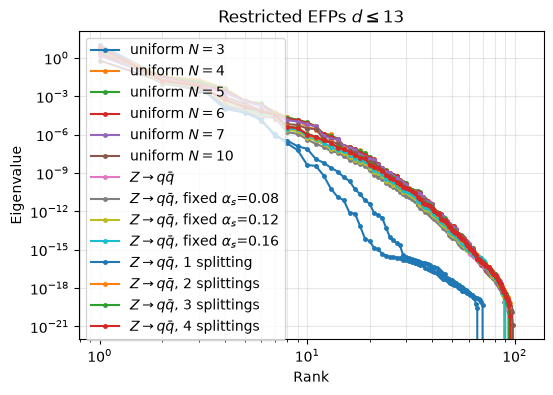

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in EFPs_evals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=5, label=labels[name])
ax.set_xlabel('Rank')
ax.set_ylabel('Eigenvalue')
ax.legend()
ax.set_title(r'Restricted EFPs $d\leq 13$')
ax.grid(True, which='both', alpha=0.3)

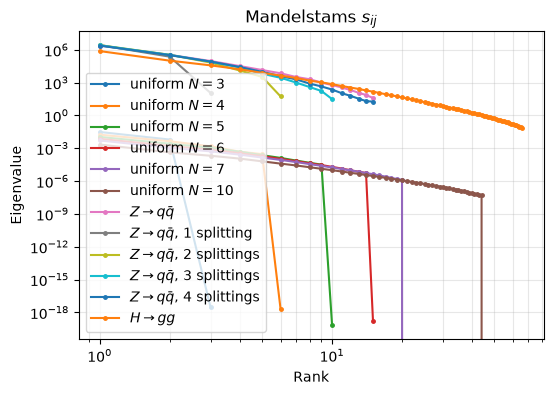

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in SIJs_evals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=5, label=labels[name])
ax.set_xlabel('Rank')
ax.set_ylabel('Eigenvalue')
ax.legend()
ax.set_title(r'Mandelstams $s_{ij}$')
ax.grid(True, which='both', alpha=0.3)

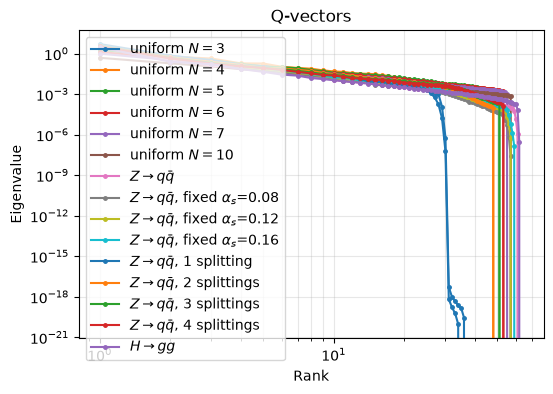

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in QVCs_evals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=5, label=labels[name])
ax.set_xlabel('Rank')
ax.set_ylabel('Eigenvalue')
ax.legend()
ax.set_title(r'Q-vectors')
ax.grid(True, which='both', alpha=0.3)

## NTK Spectra 

In [13]:
def alpha(ev, lo=50, hi=1000):
    tail = np.cumsum(ev[::-1])[::-1]; k = np.arange(1, len(tail)+1)
    return 1 - np.polyfit(np.log(k[lo:hi]), np.log(tail[lo:hi]), 1)[0]

def alpha_eig(ev, lo=20, hi=400):
    k = np.arange(1, len(ev)+1)
    return -np.polyfit(np.log(k[lo:hi]), np.log(ev[lo:hi]), 1)[0]

In [14]:
## NTK spectra, old method: full eigvalsh via kernel_spectrum on M events
M = 10_000
keys = ['u3', 'u4', 'u5', 'u6', 'u7', 'u10', 'Z', 'Z08', 'Z12', 'Z16', 'Z1', 'Z2', 'Z3', 'Z4']
NTK_EFP_dense, NTK_SIJ_dense, NTK_QVC_dense, LAPLACE_QVC_dense = {}, {}, {}, {}
for key in keys:
    t0 = time.time()
    if key in EFP_sets: NTK_EFP_dense[key] = kernel_spectrum(preprocess(EFP_sets[key][:M]), kernel="NTK", M=M)
    if key in SIJ_sets: NTK_SIJ_dense[key] = kernel_spectrum(preprocess(SIJ_sets[key][:M]), kernel="NTK", M=M)
    LAPLACE_QVC_dense[key] = kernel_spectrum(preprocess(QVC_sets[key][:M]), kernel="Laplace", M=M)
    NTK_QVC_dense[key] = kernel_spectrum(preprocess(QVC_sets[key][:M]), kernel="NTK", M=M)
    if key in EFP_sets: print(f'{labels[key]:>22}  EFP   α = {alpha_eig(NTK_EFP_dense[key], 200, 950):.2f}   ({time.time() - t0:.0f} s)')
    if key in SIJ_sets: print(f'{"":>22}  s_ij  α = {alpha_eig(NTK_SIJ_dense[key], 200, 950):.2f}')
    print(f'{"":>22}  Qvec  α = {alpha_eig(NTK_QVC_dense[key], 200, 950):.2f}')

         uniform $N=3$  EFP   α = 1.48   (58 s)
                        s_ij  α = 2.01
                        Qvec  α = 1.69
         uniform $N=4$  EFP   α = 1.22   (58 s)
                        s_ij  α = 1.22
                        Qvec  α = 1.33
         uniform $N=5$  EFP   α = 1.20   (57 s)
                        s_ij  α = 1.14
                        Qvec  α = 1.39
         uniform $N=6$  EFP   α = 1.20   (57 s)
                        s_ij  α = 1.08
                        Qvec  α = 1.43
         uniform $N=7$  EFP   α = 1.19   (57 s)
                        s_ij  α = 1.23
                        Qvec  α = 1.45
        uniform $N=10$  EFP   α = 1.18   (57 s)
                        s_ij  α = 1.40
                        Qvec  α = 1.47
        $Z\to q\bar q$  EFP   α = 1.18   (57 s)
                        s_ij  α = 1.14
                        Qvec  α = 1.29
$Z\to q\bar q$, fixed $\alpha_s$=0.08  EFP   α = 1.24   (40 s)
                        Qvec  α = 1.21
$Z\to q\bar q$, 

$s_{ij}$ inp  u3  d=2  expect 1.500  got 2.015
$s_{ij}$ inp  u4  d=5  expect 1.200  got 1.237
$s_{ij}$ inp  u5  d=8  expect 1.125  got 1.163
$s_{ij}$ inp  u6  d=11 expect 1.091  got 1.117
$s_{ij}$ inp   Z  d=var (full shower)    got 1.181
$s_{ij}$ inp  Z1  d=2  expect 1.500  got 1.496
$s_{ij}$ inp  Z2  d=5  expect 1.200  got 1.231
$s_{ij}$ inp  Z3  d=8  expect 1.125  got 1.142
$s_{ij}$ inp  Z4  d=11 expect 1.091  got 1.168
restricted E  u3  d=2  expect 1.500  got 1.489
restricted E  u4  d=5  expect 1.200  got 1.250
restricted E  u5  d=8  expect 1.125  got 1.230
restricted E  u6  d=11 expect 1.091  got 1.225
restricted E   Z  d=var (full shower)    got 1.200
restricted E  Z1  d=2  expect 1.500  got 1.479
restricted E  Z2  d=5  expect 1.200  got 1.216
restricted E  Z3  d=8  expect 1.125  got 1.198
restricted E  Z4  d=11 expect 1.091  got 1.186
$Q$-vectors   u3  d=2  expect 1.500  got 1.703
$Q$-vectors   u4  d=5  expect 1.200  got 1.361
$Q$-vectors   u5  d=8  expect 1.125  got 1.432
$Q$-v

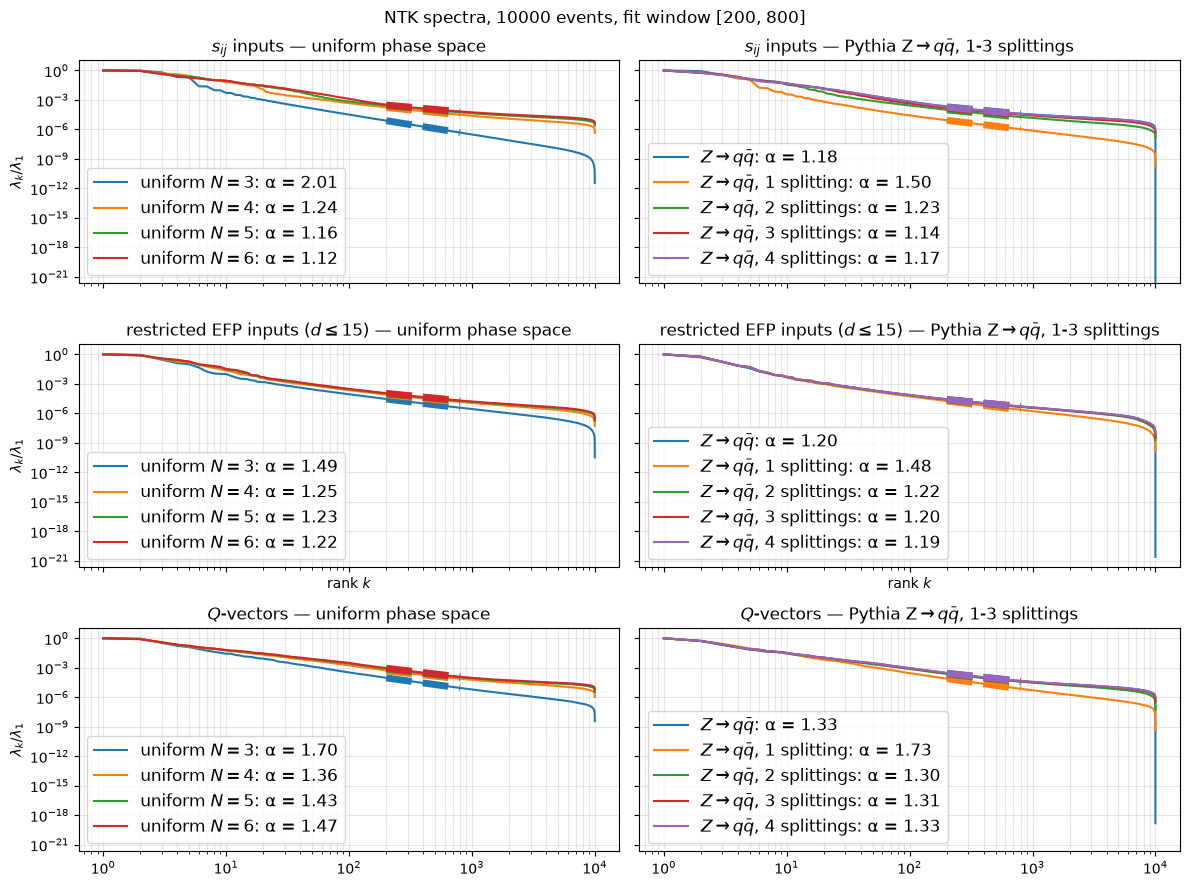

In [14]:
## 2x2: rows = input features, cols = event type; dashed = k^{-(1+1/d)} with d = 3N-7
lo, hi = 200, 800
cols = {'uniform phase space': ['u3', 'u4', 'u5', 'u6'], r'Pythia Z$\to q\bar q$, 1-3 splittings': ['Z', 'Z1', 'Z2', 'Z3', 'Z4']}
rows = {r'$s_{ij}$ inputs': NTK_SIJ_dense, r'restricted EFP inputs ($d\leq 15$)': NTK_EFP_dense, r'$Q$-vectors': NTK_QVC_dense}

fig, axs = plt.subplots(3, 2, figsize=(12, 9), sharex=True, sharey=True)
for i, (rname, L) in enumerate(rows.items()):
    for j, (cname, keys) in enumerate(cols.items()):
        ax = axs[i, j]
        for key in keys:
            lam = L[key]; 
            k = np.arange(1, len(lam) + 1)
            if key in ('Z', 'H'):  d = None                      # full shower: no fixed N
            elif key[0] == 'u':    d = 3*int(key[1:]) - 7        # uniform N-body
            else:                  d = 3*(int(key[1:]) + 2) - 7  # Z + k splittings -> N = k + 2
            a, b = np.polyfit(np.log(k[lo:hi]), np.log(lam[lo:hi]), 1)  
            expect = f'd={d:<2d} expect {1 + 1/d:.3f}' if d else 'd=var (full shower)  '
            print(f'{rname[:12]:<12} {key:>3}  {expect}  got {-a:.3f}')
            line, = ax.loglog(k, lam/lam[0], label=f'{labels[key]}: α = {-a:.2f}')
            ax.loglog(k[lo:hi], np.exp(b)*k[lo:hi]**a/lam[0], '--', color=line.get_color(), lw=5)
        ax.set_title(f'{rname} — {cname}'); 
        ax.legend(fontsize=12); 
        ax.grid(True, which='both', alpha=0.3)
for ax in axs[1]: ax.set_xlabel('rank $k$')
for ax in axs[:, 0]: ax.set_ylabel(r'$\lambda_k/\lambda_1$')
fig.suptitle(f'NTK spectra, {M} events, fit window [{lo}, {hi}]')
fig.tight_layout();

$s_{ij}$ inp  u3  d=2  expect 1.500  got 2.051
$s_{ij}$ inp  u4  d=5  expect 1.200  got 1.339
$s_{ij}$ inp  u5  d=8  expect 1.125  got 1.266
$s_{ij}$ inp  u6  d=11 expect 1.091  got 1.248
$s_{ij}$ inp  Z1  d=2  expect 1.500  got 1.628
$s_{ij}$ inp  Z2  d=5  expect 1.200  got 1.351
$s_{ij}$ inp  Z3  d=8  expect 1.125  got 1.280
$s_{ij}$ inp  Z4  d=11 expect 1.091  got 1.270
restricted E  u3  d=2  expect 1.500  got 1.595
restricted E  u4  d=5  expect 1.200  got 1.369
restricted E  u5  d=8  expect 1.125  got 1.338
restricted E  u6  d=11 expect 1.091  got 1.325
restricted E  Z1  d=2  expect 1.500  got 1.604
restricted E  Z2  d=5  expect 1.200  got 1.398
restricted E  Z3  d=8  expect 1.125  got 1.381
restricted E  Z4  d=11 expect 1.091  got 1.374


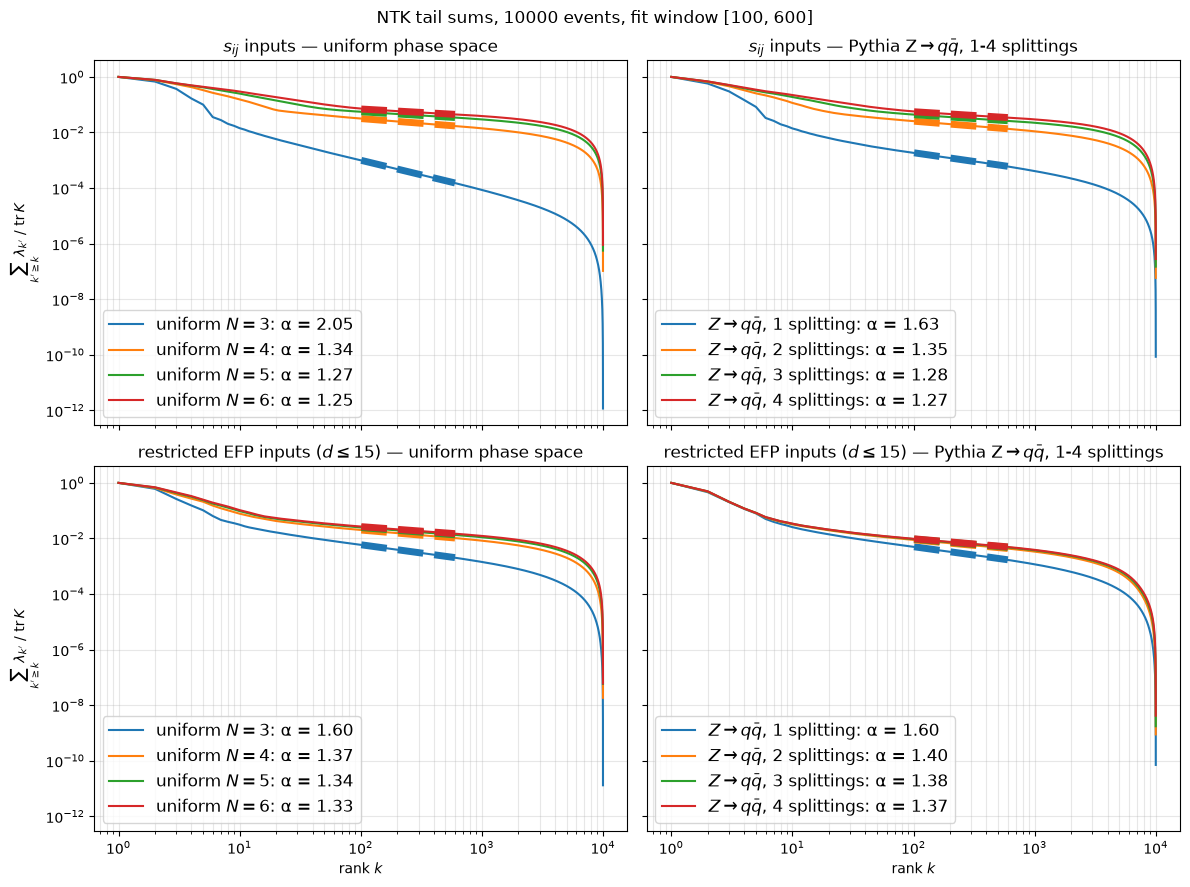

In [16]:
## Plot with np.cumsum

## 2x2, tail-sum version (Bahri et al. App. C.2): T_k = sum_{k'>=k} lambda_k' ~ k^{1-alpha}
lo, hi = 100, 600
cols = {'uniform phase space': ['u3', 'u4', 'u5', 'u6'], r'Pythia Z$\to q\bar q$, 1-4 splittings': ['Z1', 'Z2', 'Z3', 'Z4']}
rows = {r'$s_{ij}$ inputs': NTK_SIJ_dense, r'restricted EFP inputs ($d\leq 15$)': NTK_EFP_dense}

fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
for i, (rname, L) in enumerate(rows.items()):
    for j, (cname, keys) in enumerate(cols.items()):
        ax = axs[i, j]
        for key in keys:
            lam = L[key]
            T = np.cumsum(lam[::-1])[::-1]                       # tail sums, T[0] = trace
            k = np.arange(1, len(T) + 1)
            N = int(key[1:]) if key[0] == 'u' else int(key[1:]) + 2
            d = 3*N - 7
            s, b = np.polyfit(np.log(k[lo:hi]), np.log(T[lo:hi]), 1)   # slope s = 1 - alpha
            print(f'{rname[:12]:<12} {key:>3}  d={d:<2d} expect {1 + 1/d:.3f}  got {1 - s:.3f}')
            line, = ax.loglog(k, T/T[0], label=f'{labels[key]}: α = {1 - s:.2f}')
            ax.loglog(k[lo:hi], np.exp(b)*k[lo:hi]**s/T[0], '--', color=line.get_color(), lw=5)
        ax.set_title(f'{rname} — {cname}')
        ax.legend(fontsize=12)
        ax.grid(True, which='both', alpha=0.3)
for ax in axs[1]: ax.set_xlabel('rank $k$')
for ax in axs[:, 0]: ax.set_ylabel(r'$\sum_{k^\prime \geq k} \lambda_{k^\prime}\ /\ \mathrm{tr}\,K$')
fig.suptitle(f'NTK tail sums, {M} events, fit window [{lo}, {hi}]')
fig.tight_layout();

In [17]:
## NTK spectra on every feature set (Lanczos: top k_top eigenvalues of K/n, n_ev events, identical settings everywhere)
n_ev, k_top, chunk = 4_000, 2000, 5000
keys = ['u3', 'u4', 'u5', 'u6', 'u10', 'Z', 'Z1', 'Z2', 'Z3', 'Z4']
NTK_EFP_Lanczs, NTK_SIJ_Lanczs, NTK_QVC_Lanczs, LPL_QVC_Lanczs = {}, {}, {}, {}
for key in keys:
    t0 = time.time()
    NTK_EFP_Lanczs[key] = kernel_spectrum_lanczos(preprocess(EFP_sets[key][:n_ev]), kernel="NTK", k=k_top, chunk=chunk)
    NTK_SIJ_Lanczs[key] = kernel_spectrum_lanczos(preprocess(SIJ_sets[key][:n_ev]), kernel="NTK", k=k_top, chunk=chunk)
    NTK_QVC_Lanczs[key] = kernel_spectrum_lanczos(preprocess(QVC_sets[key][:n_ev]), kernel="NTK", k=k_top, chunk=chunk)
    LPL_QVC_Lanczs[key] = kernel_spectrum_lanczos(preprocess(QVC_sets[key][:n_ev]), kernel="Laplace", k=k_top, chunk=chunk)
    print(f'{labels[key]:>22}  EFP   α = {alpha_eig(NTK_EFP_Lanczs[key], 200, 950):.2f}   ({time.time() - t0:.0f} s)')
    print(f'{"":>22}  s_ij  α = {alpha_eig(NTK_SIJ_Lanczs[key], 200, 950):.2f}')
    print(f'{"":>22}  Qvec  α = {alpha_eig(NTK_QVC_Lanczs[key], 200, 950):.2f}')

         uniform $N=3$  EFP   α = 1.42   (199 s)
                        s_ij  α = 2.01
                        Qvec  α = 1.64
         uniform $N=4$  EFP   α = 1.08   (199 s)
                        s_ij  α = 1.07
                        Qvec  α = 1.17


KeyboardInterrupt: 

In [40]:
# ## 2x2: rows = input features, cols = event type; dashed = k^{-(1+1/d)} with d = 3N-7
# lo, hi = 200, 950
# cols = {'uniform phase space': ['u3', 'u4', 'u5', 'u6'], r'Pythia Z$\to q\bar q$, 1-3 splittings': ['Z1', 'Z2', 'Z3', 'Z4']}
# rows = {r'$s_{ij}$ inputs': NTK_SIJ_eigvals, r'restricted EFP inputs ($d\leq 15$)': NTK_EFP_eigvals}

# fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
# for i, (rname, L) in enumerate(rows.items()):
#     for j, (cname, keys) in enumerate(cols.items()):
#         ax = axs[i, j]
#         for key in keys:
#             lam = L[key]; 
#             k = np.arange(1, len(lam) + 1)
#             N = int(key[1:]) if key[0] == 'u' else int(key[1:]) + 2; 
#             d = 3*N - 7
#             a, b = np.polyfit(np.log(k[lo:hi]), np.log(lam[lo:hi]), 1)  
#             print(f'{rname[:12]:<12} {key:>3}  d={d:<2d} expect {1 + 1/d:.3f}  got {-a:.3f}')
#             # line, = ax.loglog(k, lam/lam[0], label=f'{labels[key]} (d={d}): α = {alpha_eig(lam, lo, hi):.2f}, expect {1 + 1/d:.2f}')
#             line, = ax.loglog(k, lam/lam[0], label=f'{labels[key]}: α = {-a:.2f}')
#             ax.loglog(k[lo:hi], np.exp(b)*k[lo:hi]**a/lam[0], '--', color=line.get_color(), lw=5)
#         ax.set_title(f'{rname} — {cname}'); 
#         ax.legend(fontsize=12); 
#         ax.grid(True, which='both', alpha=0.3)
# for ax in axs[1]: ax.set_xlabel('rank $k$')
# for ax in axs[:, 0]: ax.set_ylabel(r'$\lambda_k/\lambda_1$')
# fig.suptitle(f'NTK spectra, {n_ev} events, top {k_top} eigenvalues (Lanczos), fit window [{lo}, {hi}]')
# fig.tight_layout();

## SEMD 

In [18]:
def semd_matrix(Q, dev='cuda'):   # (n, nq) Q-vectors -> (n, n) pairwise spectral EMDs (p = 2), in radians
    Q = torch.as_tensor(Q, dtype=torch.float64, device=dev)
    return (torch.cdist(Q, Q) / np.sqrt(Q.shape[1])).cpu().numpy()

def N_of_Q(SEMD, Q):
    return (SEMD < Q).sum(1) - 1     # per-event count of neighbours within Q (minus self)

Define S, N, (mask N, Q), and d : 

In [80]:
Qs = np.logspace(-2, 0, 50)
M = 10_000
Ns, Nm, Ds, Qm = {}, {}, {}, {}
minNs = {'Z': 0.3, 'Z08': 3e3, 'Z12': 2e3, 'Z16': 1e3 }
# minNs = {'Z': 0, 'Z08': 0, 'Z12': 0, 'Z16': 0 }

for key in ['Z', 'Z08', 'Z12', 'Z16']:
    S = semd_matrix(QVC_sets[key][:M])
    Ns[key] = np.array([N_of_Q(S, Q).mean() for Q in Qs])
    ok = Ns[key] > minNs[key]                  
    Nm[key] = Ns[key][ok]        
    Qm[key] = Qs[ok]
    Ds[key] = np.gradient(np.log(Ns[key][ok]), np.log(Qm[key]))

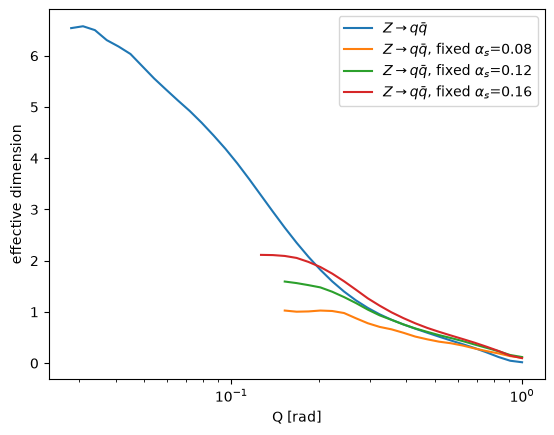

In [81]:
for key in ['Z', 'Z08', 'Z12', 'Z16']:
    plt.semilogx(Qm[key], Ds[key], label=labels[key])
plt.xlabel('Q [rad]'); plt.ylabel('effective dimension'); plt.legend()

In [ ]:
### fixed alpha plots have more 'groups of events that look similar' --> N doesn't go as small --> Q doesn't reach a small resolution

10000


(0.0, 8.0)

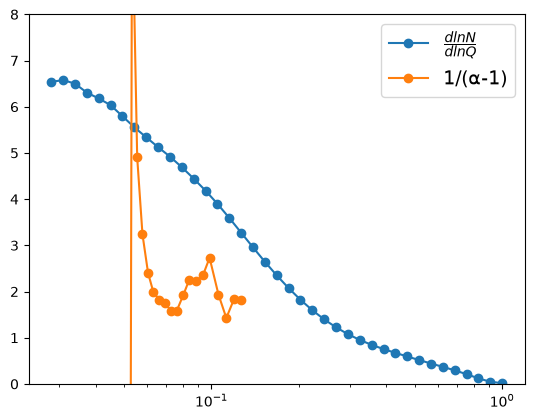

In [21]:
### ========================================= ###
### Dimension D from spectrum (lambda vs k)   ###
### ========================================= ###
sample = 'Z'
def local_alpha(ev, ks):   # slope of lambda_k in sliding windows [k, 2k]
    return [alpha_eig(ev, k, 2*k) for k in ks]

lam = NTK_QVC_dense['Z']; print(len(lam))
ks = np.unique(np.logspace(1, np.log10(len(lam)//4), 25).astype(int))
D_fromAlpha = 1 / (np.array(local_alpha(lam, ks)) - 1)        # dimension from the spectrum
Q_k = np.interp(M / ks, Nm[sample], Qm[sample])
plt.semilogx(Qm[sample], Ds[sample], 'o-', label=r'$\frac{d ln N}{d ln Q}$')
plt.semilogx(Q_k, D_fromAlpha, 'o-', label='1/(α-1)'); 

plt.legend(fontsize=14)
plt.ylim(0,8)

(1e-08, 1.0)

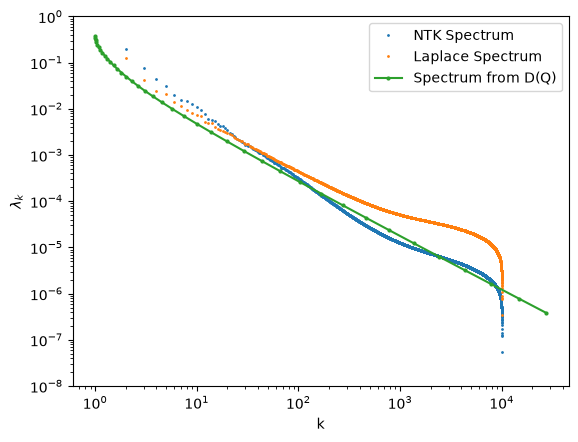

In [60]:
### =========================================== ###
### spectrum (lambda vs k) from D = dlnN/dlnQ   ###
### =========================================== ###
sample = 'Z'
### Zqq NTK Spectrum ### 
NTK_lam, LAPLACE_lam = NTK_QVC_dense[sample], LAPLACE_QVC_dense[sample]
# NTK_lam, LAPLACE_lam = NTK_QVC_Lanczs['Z'], LPL_QVC_Lanczs['Z']
ks = np.arange(1, len(NTK_lam) + 1)
plt.loglog(ks, NTK_lam, 'o', markersize=1)
plt.loglog(ks, LAPLACE_lam, 'o', markersize=1)

### Zqq NTK Spectrum from D = dlnN/dlnQ  ### 
alphas_from_D = (1 + 1/Ds[sample])[::-1]
ks_geom = (M / Nm[sample])[::-1];  ## M/N is the number of event "patches" ... function of Q, and = k 
def integral(alpha, k):   # \int_{k0}^{k} alpha dln k, trapezoid, on the sorted (k, alpha) pairs
    return np.concatenate([[0], np.cumsum(0.5*(alpha[1:] + alpha[:-1]) * np.diff(np.log(k)))])
# plt.plot(ks_geom, np.exp(integral(alphas_from_D, ks_geom), 'o-'))
plt.loglog(ks_geom, np.exp(-integral(alphas_from_D, ks_geom)) * lam[int(ks_geom[0]) - 1], 'o-', markersize=2)

plt.legend(['NTK Spectrum' , 'Laplace Spectrum' , 'Spectrum from D(Q)'])
plt.xlabel('k'); plt.ylabel(r'$\lambda_k$')
plt.ylim(1e-8, 1e0)

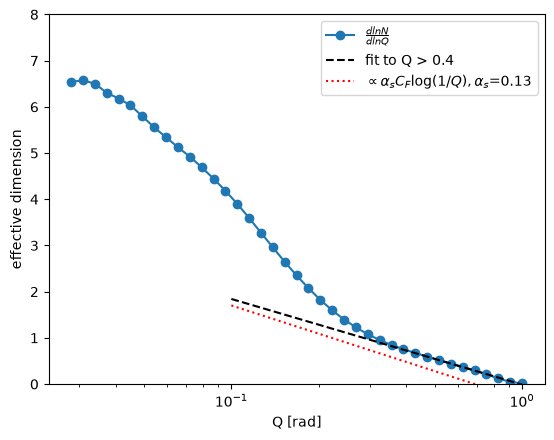

In [31]:
### Larkoski Eq. 56 check: dim(Q) at large Q should be linear in ln(1/Q)
key, alpha_s = 'Z', 0.13
Q_mask, dim = Qm[key], Ds[key]
## 
Qcut = 0.4
sel = Q_mask > Qcut
slope, icpt = np.polyfit(np.log(1/Q_mask[sel]), dim[sel], 1)
##
## Normalization
norm = 1
## 
Qline = np.logspace(-1, 0, 50)
plt.semilogx(Q_mask, dim, 'o-', label=r'$\frac{d ln N}{d ln Q}$')
plt.semilogx(Qline, slope*np.log(1/Qline) + icpt, 'k--', label=f'fit to Q > 0.4')
plt.semilogx(Qline, dim_QCD_qq(norm*Qline, alpha_s), 'r:', label=r'$\propto \alpha_s C_F \log(1/Q) , \alpha_s$=0.13')
plt.xlabel('Q [rad]'); plt.ylabel('effective dimension'); plt.ylim(0, 8); plt.legend()

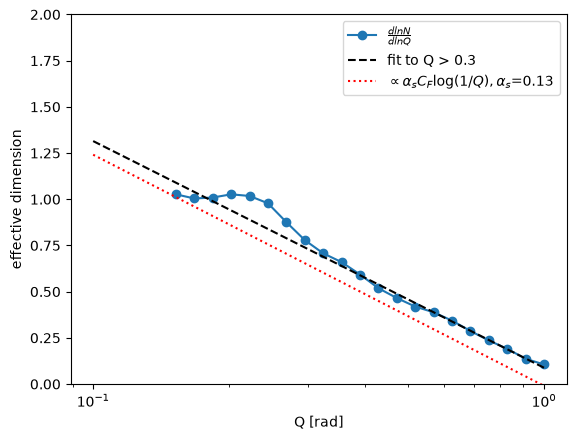

In [84]:
### Larkoski Eq. 56 check: dim(Q) at large Q should be linear in ln(1/Q) with slope 16 alpha_s C_F / pi (two quark jets)
key, alpha_s = 'Z08', 0.08
Q_mask, dim = Qm[key], Ds[key]
## 
Qcut = 0.3
sel = Q_mask > Qcut
slope, icpt = np.polyfit(np.log(1/Q_mask[sel]), dim[sel], 1)
##
## Normalization ## 
norm = 0.7
##
Qline = np.logspace(-1, 0, 50)
plt.semilogx(Q_mask, dim, 'o-', label=r'$\frac{d ln N}{d ln Q}$')
plt.semilogx(Qline, slope*np.log(1/Qline) + icpt, 'k--', label=f'fit to Q > 0.3')
plt.semilogx(Qline, dim_QCD_qq(norm*Qline, alpha_s), 'r:', label=r'$\propto \alpha_s C_F \log(1/Q) , \alpha_s$=0.13')
plt.xlabel('Q [rad]'); plt.ylabel('effective dimension'); plt.ylim(0, 2); plt.legend()

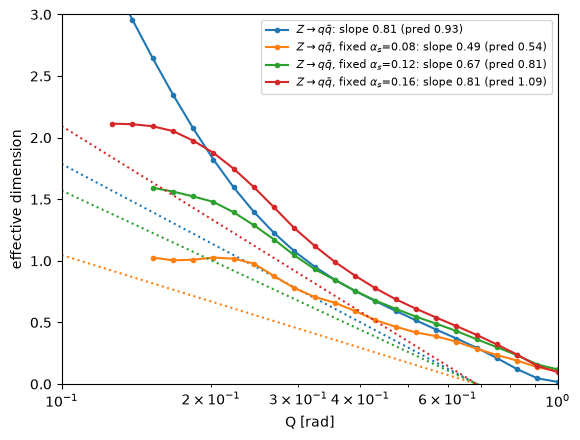

In [37]:
### Larkoski Eq. 56 check: dim(Q) at large Q should be linear in ln(1/Q) with slope 16 alpha_s C_F / pi (two quark jets)
alphas = {'Z': 0.1365, 'Z08': 0.08, 'Z12': 0.12, 'Z16': 0.16}        # 'Z' is running, quoted at M_Z
Qline = np.logspace(-1, 0, 50)
for key, alpha_s in alphas.items():
    sel = Qm[key] > 0.4
    slope, icpt = np.polyfit(np.log(1/Qm[key][sel]), Ds[key][sel], 1)
    l, = plt.semilogx(Qm[key], Ds[key], 'o-', ms=3, label=f'{labels[key]}: slope {slope:.2f} (pred {16*alpha_s*4/3/np.pi:.2f})')
    plt.semilogx(Qline, dim_QCD_qq(Qline, alpha_s), ':', color=l.get_color())
plt.xlabel('Q [rad]'); plt.ylabel('effective dimension'); 
plt.xlim(1e-1, 1e0); plt.ylim(0, 3); 
plt.legend(fontsize=8)

/tmp/ipykernel_253467/1629173960.py:9: RuntimeWarning: divide by zero encountered in log10
  z = np.logspace(np.log10(zlo), np.log10(1 - zlo), 4000)
/tmp/ipykernel_253467/1629173960.py:4: RuntimeWarning: divide by zero encountered in log
  return as_mz / (1 + b0*as_mz*np.log(mu2/mz**2))
/tmp/ipykernel_253467/1629173960.py:10: RuntimeWarning: invalid value encountered in divide
  f = alphas_run(z*(1-z)*(E*Q)**2) * (1 + (1-z)**2) / z


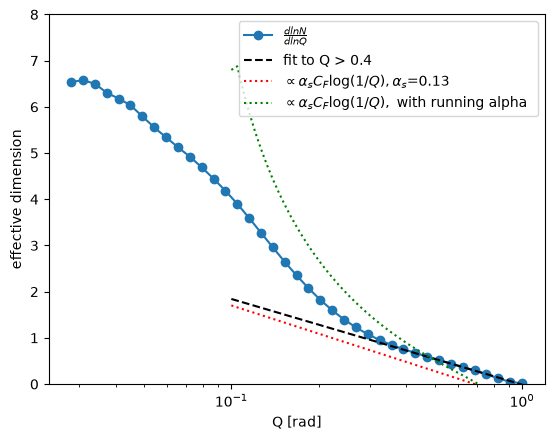

In [59]:
## Running ... 
def alphas_run(mu2, as_mz=0.1365, nf=5, mz=91.19):
    b0 = (33 - 2*nf) / (12*np.pi)
    return as_mz / (1 + b0*as_mz*np.log(mu2/mz**2))

def dim_running(Q, E=45.6, R=1.3, ptmin=0.5):
    CF = 4/3
    zlo = max(Q**2/R**2, ptmin**2/(E*Q)**2)
    z = np.logspace(np.log10(zlo), np.log10(1 - zlo), 4000)
    f = alphas_run(z*(1-z)*(E*Q)**2) * (1 + (1-z)**2) / z
    return 4*CF/np.pi * np.trapezoid(f, z)

### Larkoski Eq. 56 check: dim(Q) at large Q should be linear in ln(1/Q)
key, alpha_s = 'Z', 0.13
Q_mask, dim = Qm[key], Ds[key]
## 
Qcut = 0.4
sel = Q_mask > Qcut
slope, icpt = np.polyfit(np.log(1/Q_mask[sel]), dim[sel], 1)
##
## Normalization
norm = 1
## 
Qline = np.logspace(-1, 0, 50)
plt.semilogx(Q_mask, dim, 'o-', label=r'$\frac{d ln N}{d ln Q}$')
plt.semilogx(Qline, slope*np.log(1/Qline) + icpt, 'k--', label=f'fit to Q > 0.4')
plt.semilogx(Qline, dim_QCD_qq(norm*Qline, alpha_s), 'r:', label=r'$\propto \alpha_s C_F \log(1/Q) , \alpha_s$=0.13')
plt.semilogx(Qline, [dim_running(Q, R=1/norm) for Q in Qline], 'g:', label=r'$\propto \alpha_s C_F \log(1/Q) ,$ with running alpha ')

plt.xlabel('Q [rad]'); plt.ylabel('effective dimension'); plt.ylim(0, 8); plt.legend()

## Compute EFPs, Covariance, Spectrum

Using `measure='ee'` (appropriate for e+e- events), which uses energy fractions z_i = E_i / sum(E_j) and pairwise angles theta_ij computed from the 3-momenta directions.

Input to `batch_compute`: list of (N_particles, 4) arrays with columns (E, px, py, pz).

In [5]:
# ####################
# ## Composite EFPs ##
# ####################
# EFPs_N3_restricted_composite = np.einsum('na,nb->nab', EFPs_N3_restricted, EFPs_N3_restricted).reshape(len(EFPs_N3_restricted), -1)
# EFPs_N5_restricted_composite = np.einsum('na,nb->nab', EFPs_N5_restricted, EFPs_N5_restricted).reshape(len(EFPs_N5_restricted), -1)
# EFPs_N7_restricted_composite = np.einsum('na,nb->nab', EFPs_N7_restricted, EFPs_N7_restricted).reshape(len(EFPs_N7_restricted), -1)
# EFPs_N10_restricted_composite = np.einsum('na,nb->nab', EFPs_N10_restricted, EFPs_N10_restricted).reshape(len(EFPs_N10_restricted), -1)
# print(EFPs_N5_restricted_composite.shape)  

# EFPs_N3_composite = np.einsum('na,nb->nab', EFPs_N3, EFPs_N3).reshape(len(EFPs_N3), -1)
# EFPs_N5_composite = np.einsum('na,nb->nab', EFPs_N5, EFPs_N5).reshape(len(EFPs_N5), -1)
# EFPs_N7_composite = np.einsum('na,nb->nab', EFPs_N7, EFPs_N7).reshape(len(EFPs_N7), -1)
# EFPs_N10_composite = np.einsum('na,nb->nab', EFPs_N10, EFPs_N10).reshape(len(EFPs_N10), -1)
# EFPs_Zqq_composite = np.einsum('na,nb->nab', EFPs_Zqq, EFPs_Zqq).reshape(len(EFPs_Zqq), -1)
# EFPs_Hgg_composite = np.einsum('na,nb->nab', EFPs_Hgg, EFPs_Hgg).reshape(len(EFPs_Hgg), -1)

# EFP_sets_comp = {
#     'u3': EFPs_N3_composite, 'u5': EFPs_N5_composite,
#     'u7': EFPs_N7_composite, 'u10': EFPs_N10_composite,
#     'Z': EFPs_Zqq_composite, 'H': EFPs_Hgg_composite,
# }


# print(EFPs_N5_composite.shape)  


In [ ]:
# # Log
# eps = 1e-10
# log_EFPs_Zqq = np.log(EFPs_Zqq + eps)
# log_EFPs_Hgg = np.log(EFPs_Hgg + eps)
# log_EFPs_N3  = np.log(EFPs_N3  + eps)
# log_EFPs_N5  = np.log(EFPs_N5  + eps)
# log_EFPs_N7  = np.log(EFPs_N7  + eps)
# log_EFPs_N10  = np.log(EFPs_N10  + eps)


In [10]:
labels = {'u3': 'uniform N=3', 'u4': 'uniform N=4', 'u5': 'uniform N=5', 'u7': 'uniform N=7', 'u10': 'uniform N=10',
          'Z': 'Z->qqbar', 'H': 'H->gg',
          'Z1': 'Z->qqbar, 1 splitting', 'Z2': 'Z->qqbar, 2 splittings',
          'Z3': 'Z->qqbar, 3 splittings', 'Z4': 'Z->qqbar, 4 splittings'}


### Covariance Matrix

In [11]:
def cov_eigvals(C):
    """Eigenvalues of a covariance matrix, largest first, negatives clipped to 0."""
    return np.clip(np.linalg.eigvalsh(C)[::-1], 0, None)

covs      = {name: np.cov(X.T) for name, X in EFP_sets.items()}
covs_comp = {name: np.cov(X.T) for name, X in EFP_sets_comp.items()}
print(f"Covariance matrix shape: {covs['Z'].shape}")

Covariance matrix shape: (36, 36)


<!-- ### Eigenspectrum -->

In [12]:
eigvals      = {name: cov_eigvals(C) for name, C in covs.items()}
eigvals_comp = {name: cov_eigvals(C) for name, C in covs_comp.items()}

for name, ev in eigvals.items():
    print(f'{labels[name]}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')
for name, ev in eigvals_comp.items():
    print(f'{labels[name]} (composite): largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')

uniform N=3: largest = 8.0919e+02, smallest = 0.0000e+00
uniform N=4: largest = 5.6595e+02, smallest = 0.0000e+00
uniform N=5: largest = 3.9007e+02, smallest = 0.0000e+00
uniform N=7: largest = 2.0641e+02, smallest = 0.0000e+00
uniform N=10: largest = 1.0144e+02, smallest = 0.0000e+00
Z->qqbar: largest = 5.5481e+02, smallest = 0.0000e+00
H->gg: largest = 6.2032e+02, smallest = 0.0000e+00
Z->qqbar, 1 splitting: largest = 5.0007e+02, smallest = 0.0000e+00
Z->qqbar, 2 splittings: largest = 5.4695e+02, smallest = 0.0000e+00
Z->qqbar, 3 splittings: largest = 5.5317e+02, smallest = 0.0000e+00
Z->qqbar, 4 splittings: largest = 5.5458e+02, smallest = 0.0000e+00
uniform N=3 (composite): largest = 7.6374e+07, smallest = 0.0000e+00
uniform N=5 (composite): largest = 2.7720e+07, smallest = 0.0000e+00
uniform N=7 (composite): largest = 1.2673e+07, smallest = 0.0000e+00
uniform N=10 (composite): largest = 5.4988e+06, smallest = 0.0000e+00
Z->qqbar (composite): largest = 5.7330e+07, smallest = 0.0000

## Define, Plot Thrust 
Thrust is IRC-safe and well-approximated by low-d EFPs, so the irreducible floor should be near zero.

In [77]:
thrust_samples = {
    'Z->qqbar':    Zqq_events,
    'H->gg':       Hgg_events,
    'uniform N=3': uniform_N3,
    'uniform N=5': uniform_N5,
    'uniform N=7': uniform_N7,
    'uniform N=10': uniform_N10,
}

thrusts = {}
for name, events in thrust_samples.items():
    t = np.array([compute_thrust(e) for e in events])
    thrusts[name] = t
    print(f'{name}: mean thrust = {np.mean(t):.4f} +/- {np.std(t):.4f}')


Z->qqbar: mean thrust = 0.9351 +/- 0.0631
H->gg: mean thrust = 0.8612 +/- 0.0826
uniform N=3: mean thrust = 0.8890 +/- 0.0786
uniform N=5: mean thrust = 0.7700 +/- 0.0884
uniform N=7: mean thrust = 0.7222 +/- 0.0781
uniform N=10: mean thrust = 0.6857 +/- 0.0655


Text(0.5, 0, 'EFP Value')

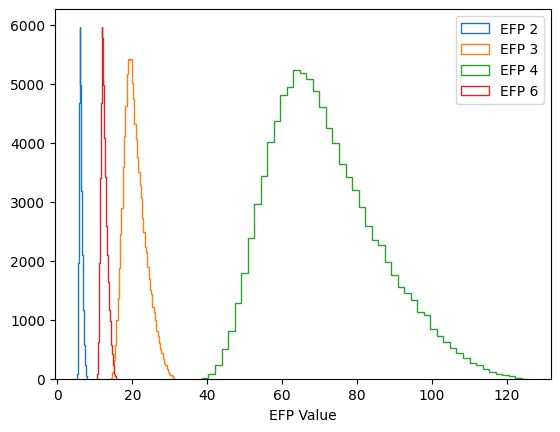

In [78]:
## Plot features ...  
plt.hist(EFPs_N5[:, 2], bins=50, histtype='step', label='EFP 2')
plt.hist(EFPs_N5[:, 3], bins=50, histtype='step', label='EFP 3')
plt.hist(EFPs_N5[:, 4], bins=50, histtype='step', label='EFP 4')
plt.hist(EFPs_N5[:, 6], bins=50, histtype='step', label='EFP 6')
plt.legend(); plt.xlabel('EFP Value')

Text(0.5, 0, 'Thrust')

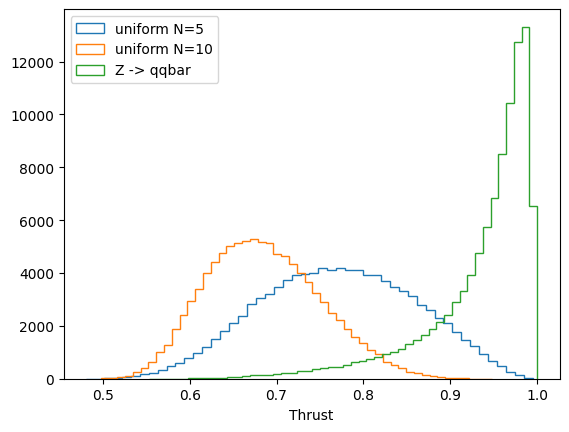

In [79]:
## Plot targets ... 
plt.hist(thrusts['uniform N=5'], bins=50, histtype='step', label='uniform N=5');
plt.hist(thrusts['uniform N=10'], bins=50, histtype='step', label='uniform N=10');
plt.hist(thrusts['Z->qqbar'], bins=50, histtype='step', label='Z -> qqbar');
plt.legend(); plt.xlabel("Thrust")

In [80]:
def kernel_eig(X, M=5000, seed=0):
    """kernel_spectrum with eigenvectors: (eigvals desc, eigvecs as columns, subsample idx). Same idx as kernel_spectrum."""
    idx = np.random.default_rng(seed).choice(len(X), min(M, len(X)), replace=False)
    Xs = torch.as_tensor(np.asarray(X)[idx], dtype=torch.float64)
    lam, U = np.linalg.eigh((ntk(Xs, Xs) / len(idx)).numpy())
    return lam[::-1], U[:, ::-1], idx


# compute once (slow cell)
NTKeig = {name: kernel_eig(Q, M=2000) for name, Q in Qsamples}   # name -> (lam, U, idx)

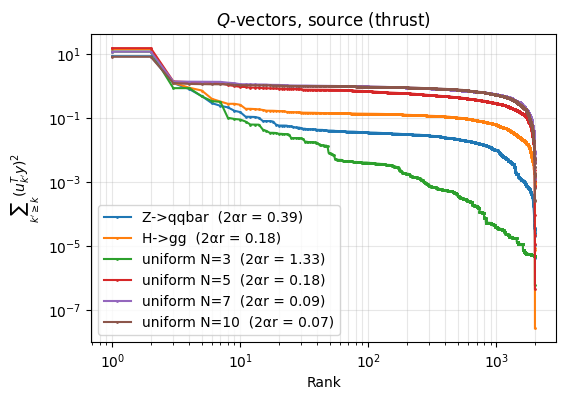

In [81]:
# Source Plot (RHS of Fig. 1, target = thrust)
fig, ax = plt.subplots(figsize=(6, 4))
for name, (lam, U, idx) in NTKeig.items():
    y = thrusts[name][idx]; y = y - y.mean()                       # centered target on the same events as K
    tail = np.cumsum(((U.T @ y)**2)[::-1])[::-1]                   # sum_{k'>=k} (u_k'^T y)^2
    k = np.arange(1, len(tail)+1)
    s = -np.polyfit(np.log(k[3:300]), np.log(tail[3:300]), 1)[0]  # = 2*alpha*r
    ax.loglog(k, tail, '.-', markersize=2, label=f'{name}  (2αr = {s:.2f})')

ax.set_xlabel('Rank')
ax.set_ylabel(r'$\sum_{k^\prime \geq k} (u_{k^\prime}^{T} y)^2$')
ax.legend()
ax.set_title(r'$Q$-vectors, source (thrust)')
ax.grid(True, which='both', alpha=0.3)

## NTK KRR: Qs → Thrust

In [25]:
import importlib, RegressFunctions
importlib.reload(RegressFunctions)
from RegressFunctions import *

In [52]:
Ps = np.unique(np.round(np.logspace(0, 3.5, 10)).astype(int))   

In [54]:
## train on NTK_Q_eigvals
λs = [1e-10]
n_reps = lambda P: max(int(500 / P), 5)
NTK_losses_Z, NTK_losses_N3, NTK_losses_N5, NTK_losses_N10 = {}, {}, {}, {}
for λ in λs: 
    NTK_losses_Z[λ]  = run_regression_sweep(Qs_Zqq, thrusts['Z->qqbar'],  Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")
    # losses_N3[r] = run_torch_regression(EFPs_N3_composite,  thrusts['uniform N=3'], train_sizes_t, r=r)
    NTK_losses_N5[λ] = run_regression_sweep(Qs_N5,  thrusts['uniform N=5'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")
    NTK_losses_N10[λ] = run_regression_sweep(Qs_N10,  thrusts['uniform N=10'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                         w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")

(80000, 61) (20000, 61) 51.2 GB per train Gram
       1  |  0.002783
       2  |  0.002125
       6  |  0.001302
      15  |  0.000440
      36  |  0.000381
      88  |  0.000224
     215  |  0.000206
     527  |  0.000146
    1292  |  0.000119
    3162  |  0.000097
(80000, 51) (20000, 51) 51.2 GB per train Gram
       1  |  0.006037
       2  |  0.004820
       6  |  0.002102
      15  |  0.001040
      36  |  0.000762
      88  |  0.000611
     215  |  0.000557
     527  |  0.000432
    1292  |  0.000366
    3162  |  0.000317
(80000, 57) (20000, 57) 51.2 GB per train Gram
       1  |  0.003512
       2  |  0.003002
       6  |  0.001462
      15  |  0.000838
      36  |  0.000758
      88  |  0.000740
     215  |  0.000706
     527  |  0.000668
    1292  |  0.000627
    3162  |  0.000591


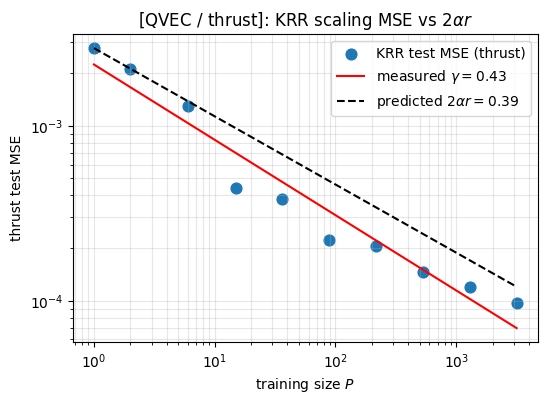

In [57]:
# Fig. 4: KRR test MSE vs n, Z->qqbar, thrust
losses, stds = NTK_losses_Z[λs[0]]
P = np.array(Ps); m = np.array(losses)
gamma = -np.polyfit(np.log(P), np.log(m), 1)[0]
two_ar = 0.39                                                   # from the source-plot fit above
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(P, m, s=60, label='KRR test MSE (thrust)')
ax.loglog(P, np.exp(np.polyval(np.polyfit(np.log(P), np.log(m), 1), np.log(P))), 'r-', label=rf'measured $\gamma = {gamma:.2f}$')
ax.loglog(P, m[0]*(P/P[0])**(-two_ar), 'k--', label=rf'predicted $2\alpha r = {two_ar:.2f}$')
ax.set_xlabel('training size $P$'); ax.set_ylabel('thrust test MSE')
ax.set_title(r'[QVEC / thrust]: KRR scaling MSE vs $2\alpha r$'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

## NTK KRR: EFPs → Thrust

In [24]:
NTK_spec_Zqq = kernel_spectrum(EFPs_Zqq,  kernel="NTK")
NTK_spec_uN5 = kernel_spectrum(EFPs_N5,   kernel="NTK")
NTK_spec_uN10 = kernel_spectrum(EFPs_N10, kernel="NTK")

Text(0, 0.5, '$\\lambda_k$')

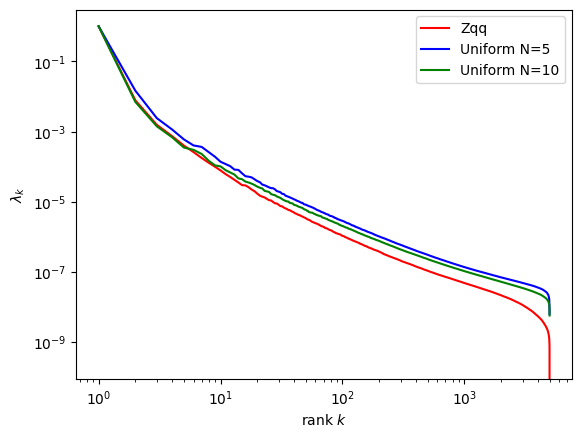

In [25]:
## Plot NTK Spectrum
i = np.arange(1, len(NTK_spec_Zqq)+1)
plt.loglog(i, NTK_spec_Zqq/NTK_spec_Zqq[0], ms=2, color='r', linestyle='-'); 
plt.loglog(i, NTK_spec_uN5/NTK_spec_uN5[0], ms=2, color='b', linestyle='-'); 
plt.loglog(i, NTK_spec_uN10/NTK_spec_uN10[0], ms=2, color='g', linestyle='-'); 
plt.legend(['Zqq', 'Uniform N=5', 'Uniform N=10'])
plt.xlabel(r'rank $k$'); plt.ylabel(r'$\lambda_k$')

In [ ]:
## Sum_k \lambda_k 
## Plot NTK Spectrum
i = np.arange(1, len(NTK_spec_Zqq)+1)
plt.loglog(i, NTK_spec_Zqq/NTK_spec_Zqq[0], ms=2, color='r', linestyle='-'); 
plt.loglog(i, NTK_spec_uN5/NTK_spec_uN5[0], ms=2, color='b', linestyle='-'); 
plt.loglog(i, NTK_spec_uN10/NTK_spec_uN10[0], ms=2, color='g', linestyle='-'); 
plt.legend(['Zqq', 'Uniform N=5', 'Uniform N=10'])
plt.xlabel(r'rank $k$'); plt.ylabel(r'$\lambda_k$')